### These: 
#### Länder mit höherem BIP pro Kopf haben eine höhere Lebenserwartung. Dargestellt in einem direkten Vergleich von jeweils 2 Ländern mit unterschiedlichem BIP pro Kopf und ähnlicher Einwohnerzahl

In [562]:
#Wichtige Imports
import pandas as pd
import matplotlib.pyplot as plt
import re

In [563]:
# Load WHO mortality data
df = pd.read_csv("Data_Files/country_lookup.csv")

# Keep only the columns we really need
df = df[["Country", "Year", "Cause", "Deaths1"]]

# Check how big the data is
print("Rows:", len(df))
print("Columns:", df.columns.tolist())


Rows: 4710902
Columns: ['Country', 'Year', 'Cause', 'Deaths1']


In [564]:
# Make sure the column is numeric
df["Deaths1"] = pd.to_numeric(df["Deaths1"], errors="coerce")

# Count missing and zero values safely
num_missing = df["Deaths1"].isna().sum()
num_zeros = (df["Deaths1"] == 0).sum()

print(f"{num_missing} NaN values in 'Deaths at all ages'")
print(f"{num_zeros} zeros in 'Deaths at all ages'")


0 NaN values in 'Deaths at all ages'
7602 zeros in 'Deaths at all ages'


In [565]:
#Wieviele Länder sind im Datensatz enthalten?
df["Country"].nunique()

124

In [566]:
#Welche Länder sind im Datensatz enthalten?
sorted(df["Country"].unique())

['Anguilla',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Bahamas',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Bermuda',
 'Bolivia',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brunei Darussalam',
 'Bulgaria',
 'Canada',
 'Cayman Islands',
 'Chile',
 'Colombia',
 'Costa Rica',
 'Croatia',
 'Cuba',
 'Cyprus',
 'Czech Republic',
 'Denmark',
 'Dominica',
 'Dominican Republic',
 'Ecuador',
 'El Salvador',
 'Estonia',
 'Fiji',
 'France',
 'French Guiana',
 'Georgia',
 'Germany',
 'Greece',
 'Grenada',
 'Guadeloupe',
 'Guatemala',
 'Guyana',
 'Haiti',
 'Honduras',
 'Hong Kong SAR',
 'Hungary',
 'Iceland',
 'Iran (Islamic Republic of)',
 'Ireland',
 'Israel',
 'Italy',
 'Jamaica',
 'Japan',
 'Jordan',
 'Kazakhstan',
 'Kiribati',
 'Kuwait',
 'Kyrgyzstan',
 'Latvia',
 'Lebanon',
 'Lithuania',
 'Luxembourg',
 'Maldives',
 'Malta',
 'Martinique',
 'Mauritius',
 'Mayotte',
 'Mexico',
 'Micronesia (Federated States of)',
 'Mongolia',
 'Mont

In [567]:
#Wieviele Einträge pro Land sind im Datensatz enthalten?
df["Country"].value_counts()


Country
Brazil                               307521
United States of America             160718
Mexico                               155631
Japan                                139281
Germany                              135943
Argentina                            120402
Colombia                             117235
Spain                                111876
Republic of Korea                    111122
France                               107980
Poland                               102952
United Kingdom, England and Wales    101342
United Kingdom                        99948
Czech Republic                        95179
Hungary                               91359
Canada                                89744
Italy                                 89164
Australia                             88616
Venezuela                             79744
Switzerland                           77883
Ecuador                               75161
Netherlands                           74636
Chile                   

In [568]:
#Wie viele Jahre sind pro Land im Datensatz enthalten?
coverage = df.groupby("Country")["Year"].nunique().reset_index(name="Years_Reported").sort_values("Years_Reported", ascending=False)
print(coverage)


                               Country  Years_Reported
27                      Czech Republic              30
28                             Denmark              29
109                        Switzerland              28
47                             Hungary              28
65                               Malta              27
58                              Kuwait              27
24                             Croatia              27
73                          Montserrat              27
54                               Japan              27
15                              Brazil              26
31                             Ecuador              26
23                          Costa Rica              26
90                   Republic of Korea              26
83                            Paraguay              26
78                           Nicaragua              26
2                            Argentina              26
51                              Israel              25
108       

In [569]:
#Direkter Vergleich ausgewählter Länder

#Ausgewählte Länder für den Vergleich
countries = [
    #High-income
    "Switzerland", "Japan", "Canada",
    #"Upper" middle-income
    "Mexico", "Colombia",
    #"Lower" middle-income
    "Brazil", "Nicaragua", "Kyrgyzstan"]

# Count entries per year for each country
counts_dict = {}
for country in countries:
    counts = df[df["Country"] == country].groupby("Year").size()
    counts_dict[country] = counts

# Combine all countries side-by-side
comparison_all = pd.concat(counts_dict, axis=1)

# Replace missing values with 0 and cast to int
comparison_all = comparison_all.fillna(0).astype(int)

print("Vergleich der Einträge pro Jahr für ausgewählte Länder:")
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
display(comparison_all)


Vergleich der Einträge pro Jahr für ausgewählte Länder:


,Switzerland,Japan,Canada,Mexico,Colombia,Brazil,Nicaragua,Kyrgyzstan
Year,,,,,,,,
1995,2880,5456,0,0,0,0,0,0
1996,2809,5363,0,0,0,18880,0,0
1997,2604,5306,0,0,4441,18299,1370,0
1998,2707,5329,0,6287,4532,18781,1296,0
1999,2679,5434,0,6067,4493,19936,1325,0
2000,2663,5390,3845,5924,4539,20318,1345,1869
2001,2722,5275,3796,5870,4730,20590,1298,1846
2002,2619,5255,3718,5847,4680,21043,1328,1910
2003,2696,5349,3731,5926,4723,8097,1453,1972


In [570]:
# Define the list of countries you want
countries = [
    # High-income
    "Switzerland", "Japan", "Canada",
    # Upper-middle-income
    "Poland", "Mexico", "Colombia",
    # Lower-middle-income
    "Brazil", "Turkey", "Nicaragua", "Kyrgyzstan"
]


# Define which years to include
years = list(range(2000, 2011))

# Filter the DataFrame
df = df[df["Country"].isin(countries) & df["Year"].isin(years)].copy()

print("After filtering:", len(df), "rows left")


After filtering: 470971 rows left


In [571]:
# Remove rows where the cause is missing or looks fake (AAA, BBB, etc.)
invalid_codes = [
    "AAA","BBB","CCC","DDD","EEE","FFF","GGG","HHH","III","JJJ","KKK",
    "LLL","MMM","NNN","OOO","PPP","QQQ","RRR","SSS","TTT","UUU","VVV",
    "WWW","XXX","YYY","ZZZ"
]

df = df[~df["Cause"].isin(invalid_codes)]

# Remove codes that start with R or Z (these are ill-defined or admin codes)
# df = df[~df["Cause"].str.startswith(("R", "Z"), na=False)]

# print("After cleaning:", len(df), "rows left")


In [572]:
import re

def categorize_icd10(code):
    """Categorize ICD-10 code into 4 broad WHO-based cause groups."""
    if not isinstance(code, str):
        return "Other/Unclassified"
    c = code.strip().upper()
    c = re.sub(r"[^A-Z0-9]", "", c)

    if re.match(r"^[AB]", c):
        return "Communicable Diseases"
    elif re.match(r"^[CDEFGHIJKLMN]", c):
        return "Noncommunicable Diseases"
    elif re.match(r"^[STVWXY]", c):
        return "Injuries & External Causes"
    else:  # O, P, Q, R, U, Z, etc.
        return "Other/Unclassified"


In [573]:
df["Category"] = df["Cause"].apply(categorize_icd10)


In [574]:
# Rebuild detailed-level dataframe with Cause
df_total = (
    df[df["Country"].isin(["Switzerland", "Japan", "Canada", "Poland", "Mexico",
                           "Colombia", "Brazil", "Turkey", "Nicaragua", "Kyrgyzstan"])]
    .groupby(["Country", "Year", "Cause"], as_index=False)["Deaths1"].sum()
)

# Reapply your categorization function
df_total["Category"] = df_total["Cause"].apply(categorize_icd10)


In [575]:
# Add up all deaths within each category for each country and year
df_grouped = (
    df.groupby(["Country", "Year", "Category"], as_index=False)["Deaths1"].sum()
)

# Calculate percentage share inside each country-year
df_grouped["Percent"] = (
    df_grouped["Deaths1"] /
    df_grouped.groupby(["Country", "Year"])["Deaths1"].transform("sum") * 100
)


In [576]:
swiss_2004 = (
    df_grouped[(df_grouped["Country"] == "Switzerland") & (df_grouped["Year"] == 2004)]
    .sort_values("Percent", ascending=False)
)
print(swiss_2004)

kyrgyzstan_2004 = (
    df_grouped[(df_grouped["Country"] == "Kyrgyzstan") & (df_grouped["Year"] == 2004)]
    .sort_values("Percent", ascending=False)
)
print(kyrgyzstan_2004)

brazil_2004 = (
    df_grouped[(df_grouped["Country"] == "Brazil") & (df_grouped["Year"] == 2004)]
    .sort_values("Percent", ascending=False)
)
print(brazil_2004)



         Country  Year                    Category  Deaths1    Percent
370  Switzerland  2004    Noncommunicable Diseases    53006  88.079096
369  Switzerland  2004  Injuries & External Causes     3541   5.884015
371  Switzerland  2004          Other/Unclassified     3038   5.048189
368  Switzerland  2004       Communicable Diseases      595   0.988701
        Country  Year                    Category  Deaths1    Percent
194  Kyrgyzstan  2004    Noncommunicable Diseases    27314  77.902002
193  Kyrgyzstan  2004  Injuries & External Causes     3601  10.270378
195  Kyrgyzstan  2004          Other/Unclassified     2999   8.553420
192  Kyrgyzstan  2004       Communicable Diseases     1148   3.274200
   Country  Year                    Category  Deaths1    Percent
18  Brazil  2004    Noncommunicable Diseases   680700  66.470130
19  Brazil  2004          Other/Unclassified   169835  16.584332
17  Brazil  2004  Injuries & External Causes   127470  12.447403
16  Brazil  2004       Communicable

In [577]:
# Select data for the country and year range
swiss_all = (
    df_grouped[
        (df_grouped["Country"] == "Switzerland") &
        (df_grouped["Year"].isin(years))
    ]
    .groupby(["Country", "Category"], as_index=False)["Deaths1"].sum()
)

# Compute percent within the total
swiss_all["Percent"] = (
    swiss_all["Deaths1"] /
    swiss_all["Deaths1"].sum() * 100
)

print(swiss_all.sort_values("Percent", ascending=False))


       Country                    Category  Deaths1    Percent
2  Switzerland    Noncommunicable Diseases   601373  88.743240
1  Switzerland  Injuries & External Causes    40093   5.916432
3  Switzerland          Other/Unclassified    29018   4.282120
0  Switzerland       Communicable Diseases     7171   1.058208


Um zwischen Ländern mit höherem und mittlerem Einkommen zu unterscheiden, werden wir die Einkommensklassifikation der Weltbank verwenden. Dort werden die Schweiz, Japan, Portugal, Kanada, Schweden und Süd Korea (Republik Korea) als High-Income Länder eingestuft, während Polen, Rumänien, Mexico und Kolumbien zu den Middle-Income Länder zählen.

Quelle: https://datahelpdesk.worldbank.org/knowledgebase/articles/906519


 Share of deaths by cause (aggregated by defined year ranges)

    Country  Communicable Diseases  Injuries & External Causes  Noncommunicable Diseases  Other/Unclassified
Switzerland                   1.05                        5.94                     88.71                4.30
      Japan                   2.13                        7.02                     87.14                3.71
     Canada                   1.74                        6.29                     89.93                2.04
     Mexico                   3.73                       11.14                     77.58                7.54
   Colombia                   3.64                       20.31                     69.29                6.75
     Brazil                   4.55                       12.61                     67.08               15.76
  Nicaragua                   4.53                       13.07                     69.15               13.24
 Kyrgyzstan                   3.54                        9.96  

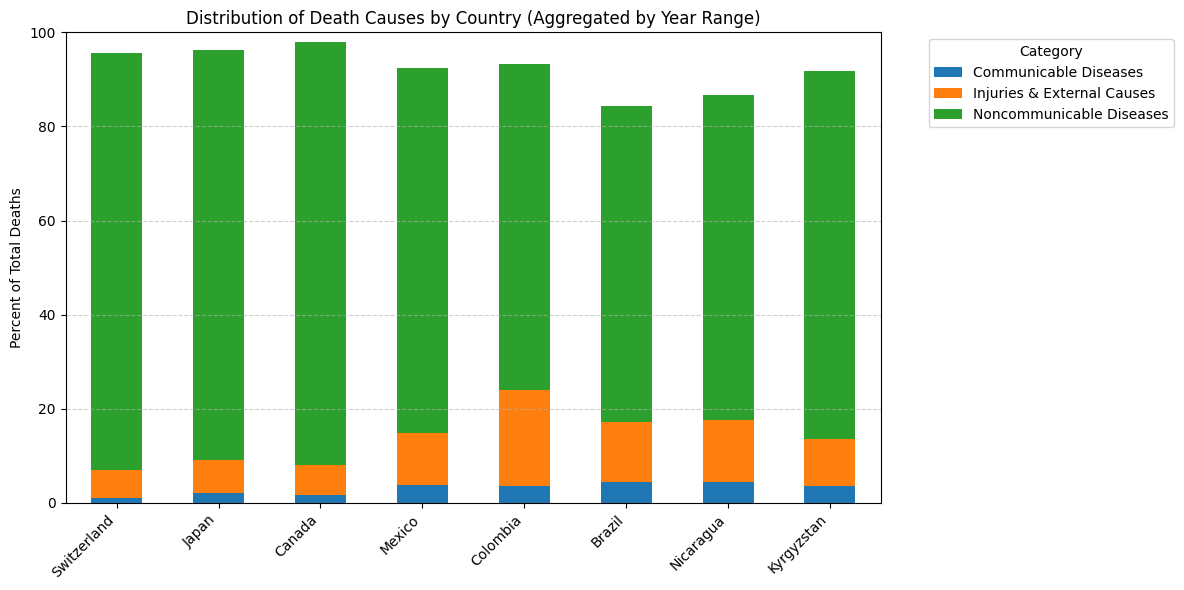

In [578]:
country_year_ranges = {
    "Switzerland": range(2000, 2010),
    "Japan": range(2000, 2010),
    "Canada": range(2000, 2010),
    "Mexico": range(2000, 2010),
    "Colombia": range(2000, 2010),
    "Brazil": range(2000, 2010),
    "Nicaragua": range(2000, 2010),
    "Kyrgyzstan": range(2000, 2010)
}

summary_list = []

for country, year_range in country_year_ranges.items():
    # Filter dataset for that country + year range
    df_sub = df_grouped[
        (df_grouped["Country"] == country)
        & (df_grouped["Year"].isin(year_range))
    ].copy()

    # Aggregate deaths by category across the full range
    df_sum = (
        df_sub.groupby(["Country", "Category"], as_index=False)["Deaths1"].sum()
    )

    # Compute share of total deaths within country
    total_deaths = df_sum["Deaths1"].sum()
    df_sum["Percent"] = (df_sum["Deaths1"] / total_deaths * 100).round(2)

    # Append results
    summary_list.append(df_sum)

# Combine all countries into one DataFrame
summary_all = pd.concat(summary_list, ignore_index=True)

# Sort cleanly
summary_all = summary_all.sort_values(["Country", "Percent"], ascending=[True, False])

summary_all["Deaths1"] = summary_all["Deaths1"].astype(int)
summary_all["Percent"] = summary_all["Percent"].round(2)

table_clean = (
    summary_all
    .pivot(index="Country", columns="Category", values="Percent")
    .fillna(0)
    .round(2)
    .reset_index()
)

# Define a logical country order (by income level)
country_order = [
    "Switzerland", "Japan", "Canada",   # High income
    "Poland", "Mexico", "Colombia",     # Upper middle
    "Brazil", "Turkey",                 # Lower middle
    "Nicaragua", "Kyrgyzstan"           # Low income
]
table_clean["Country"] = pd.Categorical(
    table_clean["Country"], categories=country_order, ordered=True
)
table_clean = table_clean.sort_values("Country")

print("\n Share of deaths by cause (aggregated by defined year ranges)\n")
print(table_clean.to_string(index=False))

# Set category order and colors
category_order = [
    "Communicable Diseases",
    "Injuries & External Causes",
    "Noncommunicable Diseases"
]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

# Plot stacked bar chart
ax = table_clean.set_index("Country")[category_order].plot(
    kind="bar", stacked=True, color=colors, figsize=(12,6)
)

plt.title("Distribution of Death Causes by Country (Aggregated by Year Range)")
plt.ylabel("Percent of Total Deaths")
plt.xlabel("")
plt.ylim(0, 100)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Category", bbox_to_anchor=(1.05, 1))
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [579]:
# Filter for Other/Unclassified causes
other_df = df_total[df_total["Category"] == "Other/Unclassified"].copy()

# Get the first letter of each ICD code
other_df["First_Letter"] = other_df["Cause"].astype(str).str[0]

# See distribution across ICD letters
print("\nLetter distribution in Other/Unclassified:")
print(other_df["First_Letter"].value_counts(normalize=True).round(3) * 100)



Letter distribution in Other/Unclassified:
First_Letter
Q    42.5
P    31.7
O    14.2
R    11.6
U     0.0
Name: proportion, dtype: float64


In [580]:

df_total = (
    df[df["Country"].isin([
        "Switzerland", "Japan", "Canada", "Poland", "Mexico",
        "Colombia", "Brazil", "Turkey", "Nicaragua", "Kyrgyzstan"
    ])]
    .groupby(["Country", "Year", "Cause"], as_index=False)["Deaths1"].sum()
)

# --- CATEGORIZE ICD-10 CODES ---
df_total["Category"] = df_total["Cause"].apply(categorize_icd10)

# --- DEFINE FUNCTION TO REFINE "OTHER/UNCLASSIFIED" ---
def refine_other(code):
    if pd.isna(code): return "Other/Unclassified"
    c = str(code).upper()
    if re.match(r"^O", c): return "Maternal Causes"
    if re.match(r"^P", c): return "Perinatal Conditions"
    if re.match(r"^Q", c): return "Congenital Disorders"
    if re.match(r"^R", c): return "Ill-defined/Unknown Causes"
    if re.match(r"^U", c): return "Special Codes (COVID, etc.)"
    if re.match(r"^Z", c): return "Health Service / Contact Factors"
    return "Other/Unclassified"

# --- ADD NEW SUBCATEGORY COLUMN ---
df_total["Other_Subcategory"] = df_total["Cause"].apply(refine_other)

# --- 🔍 COMBINE INTO A SINGLE BLOCK ---
other_breakdown = (
    df_total[df_total["Category"] == "Other/Unclassified"]
    .groupby(["Country", "Other_Subcategory"], as_index=False)["Deaths1"]
    .sum()
    .assign(
        Percent=lambda x: (
            x["Deaths1"] /
            x.groupby("Country")["Deaths1"].transform("sum") * 100
        ).round(2)
    )
    .sort_values(["Country", "Deaths1"], ascending=[True, False])
)

# --- DISPLAY RESULTS ---
print("\nBreakdown of 'Other/Unclassified' Deaths by Subcategory:")
print(other_breakdown.to_string(index=False))



Breakdown of 'Other/Unclassified' Deaths by Subcategory:
    Country           Other_Subcategory  Deaths1  Percent
     Brazil  Ill-defined/Unknown Causes  1580329    72.63
     Brazil        Perinatal Conditions   432430    19.87
     Brazil        Congenital Disorders   140049     6.44
     Brazil             Maternal Causes    23195     1.07
     Canada  Ill-defined/Unknown Causes    29620    58.08
     Canada        Perinatal Conditions    11269    22.10
     Canada        Congenital Disorders     9818    19.25
     Canada             Maternal Causes      264     0.52
     Canada Special Codes (COVID, etc.)       30     0.06
   Colombia        Perinatal Conditions    64226    45.66
   Colombia  Ill-defined/Unknown Causes    39846    28.33
   Colombia        Congenital Disorders    30532    21.71
   Colombia             Maternal Causes     6062     4.31
      Japan  Ill-defined/Unknown Causes   416526    91.95
      Japan        Congenital Disorders    26106     5.76
      Japan   

In [ ]:
#hoiiii dini muettterrrrrr